In [36]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt
from pathlib import Path

In [37]:
what_were_doing = {1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

#We'll use the linear regression formula to make a straight line with known parameters -> *Y=a+bX* or *Y=wX+b*

In [38]:
#Creating a known parameters 

weight=0.7
bias=0.3

#Create

X=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=weight*X+bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [39]:
#Let's create a training and test set with each data

#Create a train 

train_split=int(0.8*len(X))

x_train=X[:train_split]
y_train=y[:train_split]
x_test=X[train_split:]
y_test=y[train_split:]
print(f"The test_data{x_test} result is {y_test}")

The test_datatensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]]) result is tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


In [40]:
def plot_predictions(train_data=x_train,
                     train_label=y_train,
                     test_data=x_test,
                     test_label=y_test,
                     predictions=None):
    # plt.figure(figsize=(10,7))

    #Plot training data in blue

    plt.scatter(train_data,train_label,c="b",s=4,label="Training Data")

    #Plot the test data in green
    plt.scatter(test_data,test_label,c="g",s=4,label="Testing Data")

    #Now check the predictions 

    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label="Prediction")

    #Show the legend 
    plt.legend(prop={"size":14})
    plt.grid()


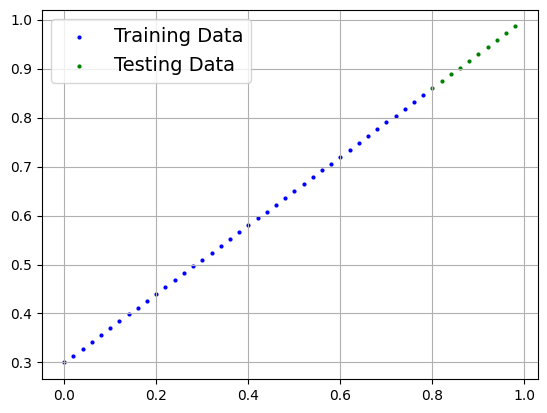

In [41]:
plot_predictions()

In [42]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [43]:
#Checking the contents of the model

#Set the manual seed for the parameters
torch.manual_seed(42)

model_0=LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [44]:
#List named parameter's 

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [45]:
#Making prediction with the model 

with torch.inference_mode():
    y_preds=model_0(x_test)

In [46]:
# Check the predictions
print(f"Number of testing samples: {len(x_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


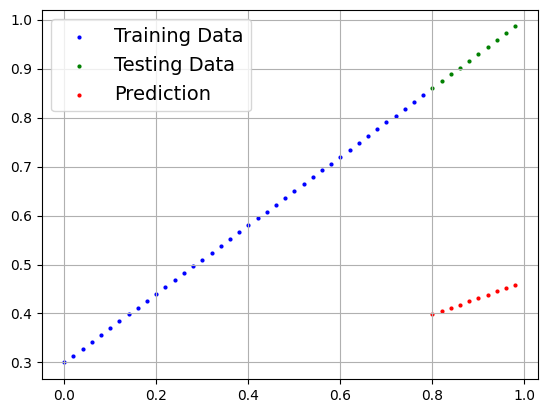

In [47]:
plot_predictions(predictions=y_preds)

In [48]:
y_preds-y_test

tensor([[-0.4618],
        [-0.4691],
        [-0.4764],
        [-0.4836],
        [-0.4909],
        [-0.4982],
        [-0.5054],
        [-0.5127],
        [-0.5200],
        [-0.5272]])

In [49]:
#Creating a loss function to get the loss of the model (Difference of prediction_value (^y) and the actual_value(y) is the loss of the model)

loss_func=nn.L1Loss()

#Optimizer is the algorithm to decide by how much changing the values(Increasing od Decreasing) of weights and the bias would affect the y(get closer to the actual value)
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)

In [50]:
# Training the Data
#Code :-

#epochs is the number of times the data loop through
epochs=200



train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    
    #Setting the parameters for the model to start the training of the model
    model_0.train()

    #1- Forward the Pass to train the model
    y_preds=model_0(x_train)

    #2- Calculate the loss function 
    loss=loss_func(y_preds,y_train)
    print(loss)

    #3- Zero grad of the optimizer
    optimizer.zero_grad()

    #4- Loss backward 
    loss.backward()

    #5- Optimize the parameters
    optimizer.step()

    #Starting the testing of the model.

    #Put the evalution mode

    model_0.eval()

    with torch.inference_mode():
        test_pred=model_0(x_test)

        test_loss=loss_func(test_pred,y_test.type(torch.float))

        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())


            print(f"Epoch: {epoch} | MAE Train Loss :{loss} | MAE Test Loss: {test_loss}")    
    

tensor(0.3129, grad_fn=<MeanBackward0>)
Epoch: 0 | MAE Train Loss :0.31288138031959534 | MAE Test Loss: 0.48106518387794495
tensor(0.3014, grad_fn=<MeanBackward0>)
tensor(0.2898, grad_fn=<MeanBackward0>)
tensor(0.2783, grad_fn=<MeanBackward0>)
tensor(0.2668, grad_fn=<MeanBackward0>)
tensor(0.2553, grad_fn=<MeanBackward0>)
tensor(0.2438, grad_fn=<MeanBackward0>)
tensor(0.2322, grad_fn=<MeanBackward0>)
tensor(0.2207, grad_fn=<MeanBackward0>)
tensor(0.2092, grad_fn=<MeanBackward0>)
tensor(0.1977, grad_fn=<MeanBackward0>)
Epoch: 10 | MAE Train Loss :0.1976713240146637 | MAE Test Loss: 0.3463551998138428
tensor(0.1862, grad_fn=<MeanBackward0>)
tensor(0.1746, grad_fn=<MeanBackward0>)
tensor(0.1631, grad_fn=<MeanBackward0>)
tensor(0.1516, grad_fn=<MeanBackward0>)
tensor(0.1401, grad_fn=<MeanBackward0>)
tensor(0.1285, grad_fn=<MeanBackward0>)
tensor(0.1170, grad_fn=<MeanBackward0>)
tensor(0.1061, grad_fn=<MeanBackward0>)
tensor(0.0968, grad_fn=<MeanBackward0>)
tensor(0.0891, grad_fn=<MeanBackw

In [51]:
# print(f"With the test_data {x_test} = {test_pred}")

"gpu" if torch.cuda.is_available() else "cpu"
# d=torch.cuda.device_count()
# print(d)

'gpu'

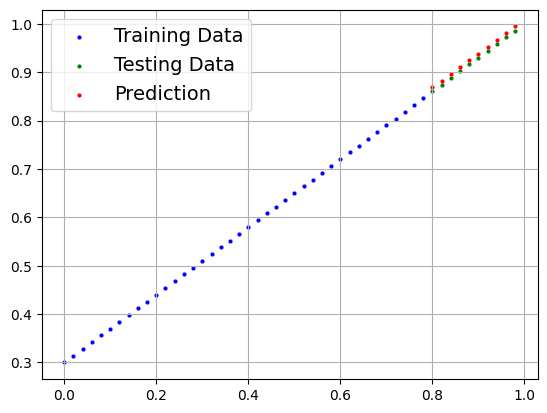

In [52]:
plot_predictions(predictions=test_pred)

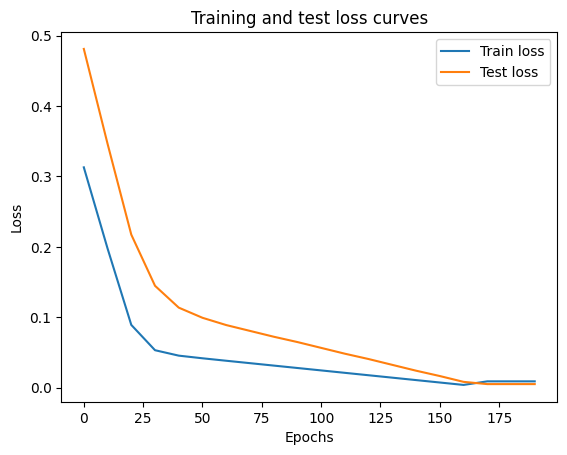

In [53]:
#Plotting the curves using the plot function

plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [55]:
#Saving the model.

#1 Create a models directory
model_path=Path("Models")
model_path.mkdir(parents=True, exist_ok=True)

#2 Create model save path
model_name="01_pytorch_model.pth"
model_save_path=model_path/model_name


torch.save(obj=model_0.state_dict(), f= model_save_path)

